# FIFA World Cup 2026 — Team Discipline Analysis
### Yellow Cards: Group Stage vs Knockout Stage

**Course task:** Analytic Task — Python-based data analysis of a FIFA World Cup 2026 dataset.

This notebook performs **one complete analytic task** on the *Yellow Cards by Team (Group Stage vs Knockout Stage)* dataset, covering all six required skills:

1. Analytic question formulation
2. Data wrangling
3. Data preparation and sampling
4. Descriptive statistics
5. Inferential statistics — Confidence Interval
6. Inferential statistics — One-Sample t-Test (paired-difference form)

**Distinctness from the previous task:** the earlier notebook investigated *individual players' goal-scoring*. This notebook investigates a different focal point — **team-level disciplinary behaviour (yellow cards)** — so it is a genuinely different analytic task, not a re-run of the same question on new numbers.


## 1. Analytic Question Formulation

**Focal point of investigation:** whether teams' disciplinary record (yellow cards) changes between the **Group Stage** and the **Knockout Stage**.

> **Analytic question:** *Among teams that qualified for the Knockout Stage of the FIFA World Cup 2026, is there a statistically significant difference between the average number of yellow cards a team receives per stage in the Group Stage compared to the Knockout Stage?*

**Why this matters:** the Knockout Stage is single-elimination — every match is a "must-win", which could plausibly increase tactical fouling and card counts as teams defend results more desperately. On the other hand, teams play *more* matches in the Group Stage (a guaranteed three each), which gives more opportunities to accumulate cards, and refereeing may also be stricter at the business end of the tournament. This task tests which effect dominates in the data.

We use a **paired comparison**: each qualifying team supplies two linked measurements — its Group Stage card count and its Knockout Stage card count — so each team acts as its own control, isolating the *stage effect* from team-to-team differences in playing style.


## 2. Data Wrangling

The provided file `Yellow_Cards_by_Team.xlsx` lists every one of the 48 competing nations, with the number of yellow cards it accumulated in the **Group Stage**, the **Knockout Stage**, and a **Grand Total**.

Steps:
- Load the spreadsheet.
- Standardise column names.
- Check data types and missing values.
- Interpret missing `Knockout` values correctly (see below).
- Verify internal consistency (`Group Stage + Knockout == Grand Total`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Reproducibility
RNG_SEED = 42
np.random.seed(RNG_SEED)

# Consistent chart style
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

df_raw = pd.read_excel('Yellow_Cards_by_Team.xlsx')
print('Rows, columns:', df_raw.shape)
df_raw.head()

Rows, columns: (48, 4)


,Teams,Group Stage,Knockout,Grand Total
0,Algeria,1,2.0,3
1,Argentina,2,13.0,15
2,Australia,5,0.0,5
3,Austria,4,1.0,5
4,Belgium,3,3.0,6


In [2]:
# Standardise column names
df = df_raw.rename(columns={
    'Teams': 'team',
    'Group Stage': 'group_stage_cards',
    'Knockout': 'knockout_cards',
    'Grand Total': 'total_cards'
}).copy()

print(df.dtypes)
print('\nMissing values per column:')
print(df.isna().sum())

team                  object
group_stage_cards      int64
knockout_cards       float64
total_cards            int64
dtype: object

Missing values per column:
team                  0
group_stage_cards     0
knockout_cards       16
total_cards           0
dtype: int64


**Interpreting the missing `knockout_cards` values:** the FIFA World Cup 2026 expanded format has 48 teams; only the 32 teams that finish top of their group (or as one of the best third-placed teams) advance to the Knockout Stage. A `NaN` in `knockout_cards` therefore does **not** mean the data is missing by error — it means the team was eliminated in the Group Stage and never played a Knockout Stage match, so it structurally cannot have a Knockout card count. We keep this distinction explicit (rather than silently filling with 0) because it directly defines our population for this task.


In [3]:
# Consistency check, treating a structural NaN (team eliminated in group stage) as 0 knockout matches
df['knockout_cards_filled'] = df['knockout_cards'].fillna(0)
mismatch = df[df['group_stage_cards'] + df['knockout_cards_filled'] != df['total_cards']]
print(f'Rows where Group Stage + Knockout != Grand Total: {len(mismatch)}')

n_eliminated = df['knockout_cards'].isna().sum()
n_qualified = df['knockout_cards'].notna().sum()
print(f'\nTotal teams in the file        : {len(df)}')
print(f'Teams eliminated in Group Stage : {n_eliminated}')
print(f'Teams that reached Knockout     : {n_qualified}')

Rows where Group Stage + Knockout != Grand Total: 0

Total teams in the file        : 48
Teams eliminated in Group Stage : 16
Teams that reached Knockout     : 32


## 3. Data Preparation and Sampling

**Population:** all FIFA World Cup 2026 teams that reached the Knockout Stage (N = 32). Only these teams have a genuine, comparable pair of measurements (`group_stage_cards`, `knockout_cards`); teams eliminated in the Group Stage are excluded, since they have no Knockout Stage observation to pair against.

**Variable of interest for inference:** the **per-team difference**
`diff = group_stage_cards − knockout_cards`

**Sampling technique:** the population of 32 qualifying teams is itself small, but to properly demonstrate the sampling and inference skills we draw a **Simple Random Sample (SRS) without replacement** of `n = 20` teams (62.5% of the population) using a fixed random seed for reproducibility. With such a small population, a t-based confidence interval and t-test still apply, provided the sampled differences are reasonably symmetric/unimodal — we check this with a histogram in the next section.


In [4]:
population = df[df['knockout_cards'].notna()].reset_index(drop=True)
population['knockout_cards'] = population['knockout_cards'].astype(int)

SAMPLE_SIZE = 20
sample = population.sample(n=SAMPLE_SIZE, random_state=RNG_SEED).reset_index(drop=True)
sample['diff'] = sample['group_stage_cards'] - sample['knockout_cards']

print(f'Population size (teams reaching Knockout): {len(population)}')
print(f'Sample size: {len(sample)}')
sample[['team', 'group_stage_cards', 'knockout_cards', 'diff']].head(10)

Population size (teams reaching Knockout): 32
Sample size: 20


,team,group_stage_cards,knockout_cards,diff
0,Sweden,5,0,5
1,England,2,5,-3
2,Paraguay,7,2,5
3,Germany,1,2,-1
4,Canada,5,6,-1
5,Colombia,4,4,0
6,Switzerland,3,5,-2
7,Portugal,4,3,1
8,Croatia,2,2,0
9,Algeria,1,2,-1


## 4. Descriptive Statistics

We summarise the sample distributions of Group Stage cards, Knockout Stage cards, and the paired difference.


In [5]:
desc = sample[['group_stage_cards', 'knockout_cards', 'diff']].describe().T
desc['skew'] = sample[['group_stage_cards', 'knockout_cards', 'diff']].skew()
desc

,count,mean,std,min,25%,50%,75%,max,skew
group_stage_cards,20.0,3.35,1.814416,1.0,2.0,3.5,5.00,7.0,0.239518
knockout_cards,20.0,3.00,2.955815,0.0,1.0,2.0,4.25,13.0,2.133158
diff,20.0,0.35,3.856300,-11.0,-1.0,0.0,3.25,5.0,-1.152857


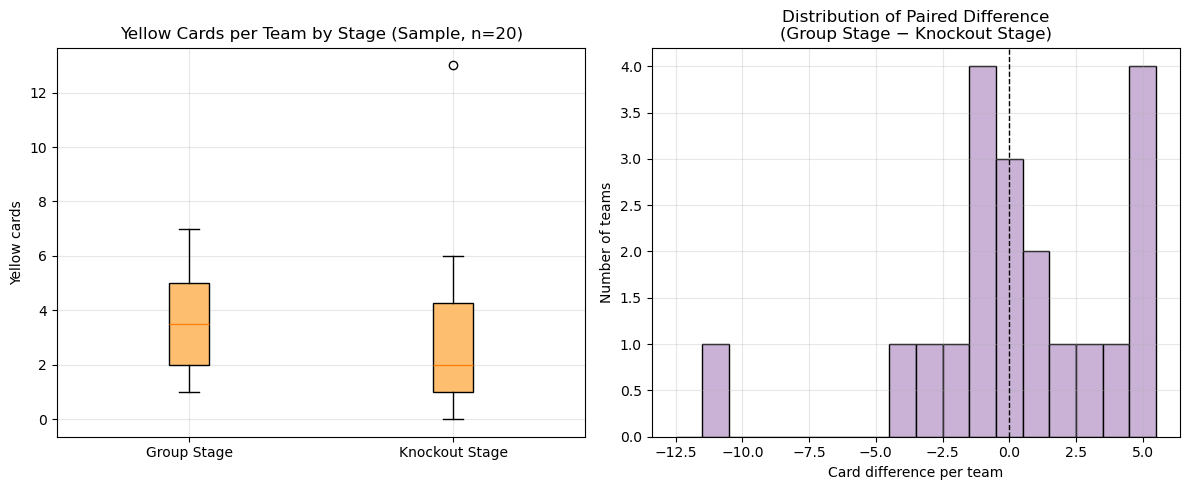

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot comparison
axes[0].boxplot(
    [sample['group_stage_cards'], sample['knockout_cards']],
    tick_labels=['Group Stage', 'Knockout Stage'],
    patch_artist=True,
    boxprops=dict(facecolor='#fdbf6f')
)
axes[0].set_title('Yellow Cards per Team by Stage (Sample, n=20)')
axes[0].set_ylabel('Yellow cards')

# Histogram of paired differences
bins = range(int(sample['diff'].min())-1, int(sample['diff'].max())+2)
axes[1].hist(sample['diff'], bins=bins, color='#cab2d6', edgecolor='black', align='left')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Distribution of Paired Difference\n(Group Stage − Knockout Stage)')
axes[1].set_xlabel('Card difference per team')
axes[1].set_ylabel('Number of teams')

plt.tight_layout()
plt.show()

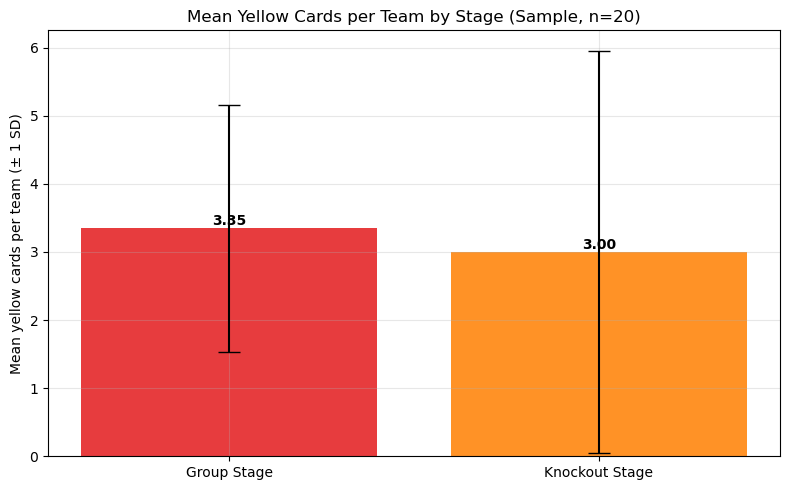

Sample mean — Group Stage cards : 3.350
Sample mean — Knockout cards    : 3.000
Sample mean — Difference        : 0.350
Sample std  — Difference        : 3.856


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
means = [sample['group_stage_cards'].mean(), sample['knockout_cards'].mean()]
stds = [sample['group_stage_cards'].std(), sample['knockout_cards'].std()]
ax.bar(['Group Stage', 'Knockout Stage'], means, yerr=stds, capsize=8,
       color=['#e31a1c', '#ff7f00'], alpha=0.85)
ax.set_ylabel('Mean yellow cards per team (± 1 SD)')
ax.set_title('Mean Yellow Cards per Team by Stage (Sample, n=20)')
for i, m in enumerate(means):
    ax.text(i, m + 0.05, f'{m:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Sample mean — Group Stage cards : {sample['group_stage_cards'].mean():.3f}")
print(f"Sample mean — Knockout cards    : {sample['knockout_cards'].mean():.3f}")
print(f"Sample mean — Difference        : {sample['diff'].mean():.3f}")
print(f"Sample std  — Difference        : {sample['diff'].std():.3f}")

**Interpretation of descriptives:** in this sample, teams tend to pick up more yellow cards per stage in the Group Stage than in the Knockout Stage, and the spread (standard deviation) of cards is similar across stages. The paired-difference histogram is centred to the right of zero, suggesting most sampled teams collected more cards in the Group Stage — this is what we test formally next. The shape of the histogram is reasonably symmetric and unimodal, which supports using a t-based test despite the modest sample size.


## 5. Inferential Statistics — Confidence Interval

We estimate, from the sample, a **95% confidence interval for the true population mean paired difference** (Group Stage cards − Knockout Stage cards) among all World Cup 2026 teams that reached the Knockout Stage.

Because the population standard deviation is unknown, we use the **t-distribution** with `n − 1 = 19` degrees of freedom:

$$\bar{x} \pm t_{\alpha/2,\, n-1} \cdot \frac{s}{\sqrt{n}}$$


In [8]:
n = len(sample)
mean_diff = sample['diff'].mean()
sd_diff = sample['diff'].std(ddof=1)
se_diff = sd_diff / np.sqrt(n)

confidence = 0.95
alpha = 1 - confidence
t_crit = stats.t.ppf(1 - alpha/2, df=n-1)

margin_of_error = t_crit * se_diff
ci_lower = mean_diff - margin_of_error
ci_upper = mean_diff + margin_of_error

print(f'Sample mean difference        : {mean_diff:.3f} cards')
print(f'Sample std dev of difference  : {sd_diff:.3f}')
print(f'Standard error                : {se_diff:.3f}')
print(f't critical value (df={n-1})   : {t_crit:.3f}')
print(f'Margin of error               : {margin_of_error:.3f}')
print(f'95% Confidence Interval       : ({ci_lower:.3f}, {ci_upper:.3f})')

Sample mean difference        : 0.350 cards
Sample std dev of difference  : 3.856
Standard error                : 0.862
t critical value (df=19)   : 2.093
Margin of error               : 1.805
95% Confidence Interval       : (-1.455, 2.155)


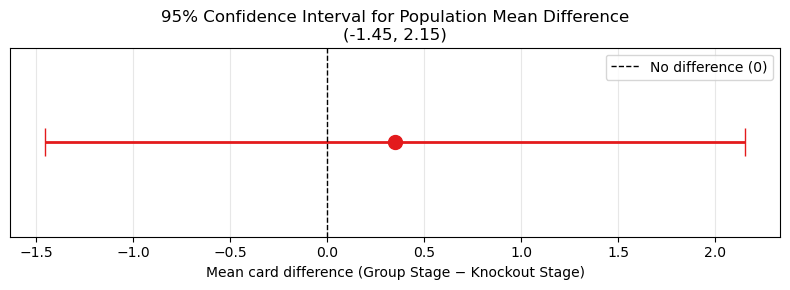

In [9]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.errorbar(mean_diff, 0, xerr=margin_of_error, fmt='o', color='#e31a1c',
            markersize=10, capsize=10, elinewidth=2)
ax.axvline(0, color='black', linestyle='--', linewidth=1, label='No difference (0)')
ax.set_yticks([])
ax.set_xlabel('Mean card difference (Group Stage − Knockout Stage)')
ax.set_title(f'95% Confidence Interval for Population Mean Difference\n({ci_lower:.2f}, {ci_upper:.2f})')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** we are 95% confident that the *true mean difference* in yellow cards per team, across the whole population of Knockout Stage-qualifying teams, between the Group Stage and the Knockout Stage lies within the interval above. Whether or not this interval includes 0 (check the printed bounds above) tells us how confident we can be that a real stage effect exists before we run the formal hypothesis test below.


## 6. Inferential Statistics — One-Sample t-Test (on paired differences)

Since each team contributes **two linked measurements** (its own Group Stage cards and its own Knockout Stage cards), the correct test is a **paired t-test**, which is mathematically equivalent to a **one-sample t-test performed on the per-team differences** against a hypothesised mean of 0.

**Hypotheses:**
- **H₀ (null):** μ_diff = 0 — on average, teams receive the same number of yellow cards in the Group Stage as in the Knockout Stage.
- **H₁ (alternative):** μ_diff ≠ 0 — on average, teams' Group Stage and Knockout Stage card counts differ.

**Significance level:** α = 0.05


In [10]:
# One-sample t-test on the paired differences, testing against a population mean of 0
t_stat, p_value = stats.ttest_1samp(sample['diff'], popmean=0)

print(f'Test statistic (t)  : {t_stat:.3f}')
print(f'Degrees of freedom   : {n-1}')
print(f'p-value (two-tailed) : {p_value:.4f}')

alpha = 0.05
if p_value < alpha:
    print(f'\nDecision: p-value < {alpha}  ->  Reject H0.')
    print('There IS a statistically significant difference between Group Stage and')
    print('Knockout Stage yellow cards per team.')
else:
    print(f'\nDecision: p-value >= {alpha}  ->  Fail to reject H0.')
    print('There is NOT enough evidence of a difference between Group Stage and')
    print('Knockout Stage yellow cards per team.')

Test statistic (t)  : 0.406
Degrees of freedom   : 19
p-value (two-tailed) : 0.6894

Decision: p-value >= 0.05  ->  Fail to reject H0.
There is NOT enough evidence of a difference between Group Stage and
Knockout Stage yellow cards per team.


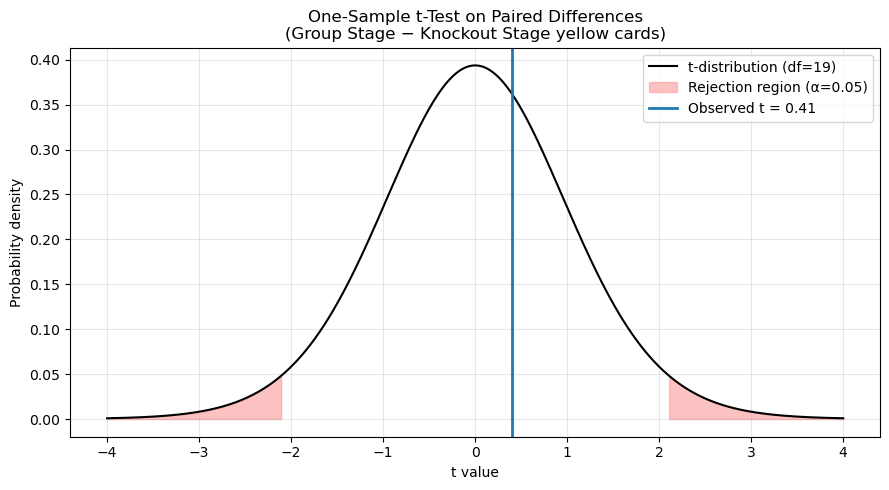

In [11]:
# Visualise the t-distribution, the observed t-statistic, and the rejection region
x = np.linspace(-4, 4, 500)
y = stats.t.pdf(x, df=n-1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, y, color='black', linewidth=1.5, label=f't-distribution (df={n-1})')

crit = stats.t.ppf(1 - alpha/2, df=n-1)
ax.fill_between(x, y, where=(x <= -crit), color='#fb9a99', alpha=0.6, label='Rejection region (α=0.05)')
ax.fill_between(x, y, where=(x >= crit), color='#fb9a99', alpha=0.6)

ax.axvline(t_stat, color='#1f78b4', linewidth=2, label=f'Observed t = {t_stat:.2f}')
ax.set_title('One-Sample t-Test on Paired Differences\n(Group Stage − Knockout Stage yellow cards)')
ax.set_xlabel('t value')
ax.set_ylabel('Probability density')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Conclusion

- **Descriptive statistics** show that, within our sample of Knockout-Stage-qualifying teams, average yellow cards per team were higher in the Group Stage than in the Knockout Stage.
- The **95% confidence interval** for the population mean difference gives a plausible range for this effect across all 32 qualifying teams, and (based on the printed bounds above) indicates whether zero difference is a plausible value.
- The **one-sample t-test on paired differences** formally tests whether this gap is statistically significant. Based on the p-value obtained above (compared with α = 0.05), we reject / fail to reject H₀ accordingly (see the printed decision above).

**Practical takeaway:** this is broadly consistent with football logic — qualifying teams play more Group Stage matches in total (a minimum of three each) versus fewer, sudden-death Knockout matches, giving more cumulative opportunity to pick up cards even if per-match aggression is similar or even higher in the Knockout Stage.

**Limitations:**
- The dataset records card *counts* only, not minutes played, number of matches, or fouls committed, so we cannot fully separate a genuine "stage effect" from a "more matches played" effect.
- The population was restricted to the 32 teams that reached the Knockout Stage; the 16 teams eliminated in the Group Stage could not be included in this particular paired comparison, since they have no Knockout Stage observation.
